# Single Config Training — FFT/Hop Experiment

Bu notebook'u her config icin bir kez calistir.  
Sadece asagidaki `CONFIG_NAME` hucresini degistirmen yeterli.

Mevcut config'ler:
```
fft512_hop128_mel128_seg3
fft512_hop256_mel128_seg3
fft512_hop512_mel128_seg3
fft1024_hop128_mel128_seg3
fft1024_hop256_mel128_seg3
fft1024_hop512_mel128_seg3
fft2048_hop128_mel128_seg3
fft2048_hop256_mel128_seg3
fft2048_hop512_mel128_seg3
```

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Config — SADECE BURAYI DEGISTIR

In [2]:
#############################################
#  HER CALISTIRMADA SADECE BUNU DEGISTIR    #
#############################################
CONFIG_NAME = "fft2048_hop128_mel128_seg3"
#############################################

import os
import numpy as np
import tensorflow as tf
import json
import time

FEATURE_ROOT = "/content/drive/MyDrive/GTZAN PAPER/extracted_features_with_segments_new"
BATCH_SIZE   = 32
EPOCHS       = 120
N_RUNS       = 5
SEEDS        = [42, 123, 456, 789, 1024]

GENRE_NAMES = ['blues', 'classical', 'country', 'disco', 'hiphop',
               'jazz', 'metal', 'pop', 'reggae', 'rock']

SPLIT_DIR   = os.path.join(FEATURE_ROOT, CONFIG_NAME, "track_level_split")
RESULTS_DIR = os.path.join(FEATURE_ROOT, "experiment_results")
CONFIG_RESULTS_DIR = os.path.join(RESULTS_DIR, CONFIG_NAME)
os.makedirs(CONFIG_RESULTS_DIR, exist_ok=True)

print(f"Config: {CONFIG_NAME}")
print(f"Path:   {SPLIT_DIR}")
print(f"Exists: {os.path.exists(SPLIT_DIR)}")

Config: fft2048_hop128_mel128_seg3
Path:   /content/drive/MyDrive/GTZAN PAPER/extracted_features_with_segments_new/fft2048_hop128_mel128_seg3/track_level_split
Exists: True


## 2. Load Data

In [3]:
X_train = np.load(os.path.join(SPLIT_DIR, "X_train.npy"))
y_train = np.load(os.path.join(SPLIT_DIR, "y_train.npy"))
X_val   = np.load(os.path.join(SPLIT_DIR, "X_val.npy"))
y_val   = np.load(os.path.join(SPLIT_DIR, "y_val.npy"))
X_test  = np.load(os.path.join(SPLIT_DIR, "X_test.npy"))
y_test  = np.load(os.path.join(SPLIT_DIR, "y_test.npy"))

num_classes = len(np.unique(y_train))
input_shape = X_train.shape[1:]

print(f"Input shape : {input_shape}")
print(f"Classes     : {num_classes}")
print(f"Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")

Input shape : (128, 517, 1)
Classes     : 10
Train: 6990  Val: 1500  Test: 1500


## 3. Track Indices (Majority Voting icin)

In [4]:
from collections import Counter
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


def load_track_indices(split_dir, split_name):
    """Track indekslerini yukle veya olustur."""
    json_path = os.path.join(split_dir, f"{split_name}_tracks.json")
    y = np.load(os.path.join(split_dir, f"y_{split_name}.npy"))
    n_segments = len(y)

    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            track_list = json.load(f)

        # Eger track_list segment bazinda degilse (track sayisi kadar eleman varsa)
        # her track'i 10 segmente genislet
        if len(track_list) != n_segments:
            segs_per_track = n_segments // len(track_list)
            track_list_expanded = []
            for t in track_list:
                track_list_expanded.extend([t] * segs_per_track)
            # kalan varsa son track'e ekle
            while len(track_list_expanded) < n_segments:
                track_list_expanded.append(track_list[-1])
            track_list = track_list_expanded

        unique_tracks = list(dict.fromkeys(track_list))
        track_to_idx = {t: i for i, t in enumerate(unique_tracks)}
        track_indices = np.array([track_to_idx[t] for t in track_list])
    else:
        # Fallback: 10 segment per track
        segs_per_track = 10
        n_tracks = n_segments // segs_per_track
        track_indices = np.repeat(np.arange(n_tracks), segs_per_track)
        if len(track_indices) < n_segments:
            extra = n_segments - len(track_indices)
            track_indices = np.concatenate([track_indices, np.full(extra, n_tracks - 1)])

    print(f"  {split_name}: {n_segments} segments -> {len(np.unique(track_indices))} tracks")
    return track_indices


def majority_vote(y_true, y_pred, track_indices):
    """Segment tahminlerini track bazinda birlestir."""
    track_true, track_pred = [], []
    for tid in np.unique(track_indices):
        mask = track_indices == tid
        track_true.append(y_true[mask][0])
        track_pred.append(Counter(y_pred[mask]).most_common(1)[0][0])
    return np.array(track_true), np.array(track_pred)


test_track_indices = load_track_indices(SPLIT_DIR, "test")

  test: 1500 segments -> 150 tracks


## 4. Model & Training (5 Seeds)

In [5]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import gc


def build_model(input_shape, num_classes):
    REG = regularizers.l2(5e-4)
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=REG),
        layers.BatchNormalization(),
        layers.SpatialDropout2D(0.15),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=REG),
        layers.BatchNormalization(),
        layers.SpatialDropout2D(0.2),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=REG),
        layers.BatchNormalization(),
        layers.SpatialDropout2D(0.25),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu", kernel_regularizer=REG),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )
    return model


# One-hot
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_oh   = tf.keras.utils.to_categorical(y_val, num_classes)
y_test_oh  = tf.keras.utils.to_categorical(y_test, num_classes)

# --- 5 seed ile egitim ---
run_results = []

for run_idx, seed in enumerate(SEEDS):
    print(f"\n--- Run {run_idx+1}/{N_RUNS} (seed={seed}) ---")
    tf.keras.utils.set_random_seed(seed)

    # Pipeline
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train_oh))
    train_ds = train_ds.shuffle(len(X_train), seed=seed).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val_oh)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_oh)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # Model
    model = build_model(input_shape, num_classes)

    seed_dir = os.path.join(CONFIG_RESULTS_DIR, f"seed_{seed}")
    os.makedirs(seed_dir, exist_ok=True)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
        ModelCheckpoint(os.path.join(seed_dir, "best_model.keras"), monitor="val_loss", save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    ]

    # Train
    t0 = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=2
    )
    train_time = time.time() - t0

    # --- Segment-level ---
    test_loss, test_acc_seg = model.evaluate(test_ds, verbose=0)
    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred_seg = np.argmax(y_pred_probs, axis=1)
    seg_f1_macro = float(f1_score(y_test, y_pred_seg, average='macro'))
    seg_f1_per_class = f1_score(y_test, y_pred_seg, average=None).tolist()
    seg_cm = confusion_matrix(y_test, y_pred_seg).tolist()

    # --- Track-level ---
    y_true_track, y_pred_track = majority_vote(y_test, y_pred_seg, test_track_indices)
    test_acc_track = float(accuracy_score(y_true_track, y_pred_track))
    track_f1_macro = float(f1_score(y_true_track, y_pred_track, average='macro'))
    track_f1_per_class = f1_score(y_true_track, y_pred_track, average=None).tolist()
    track_cm = confusion_matrix(y_true_track, y_pred_track).tolist()

    # --- Best epoch ---
    best_epoch = int(np.argmin(history.history['val_loss']))
    train_acc = history.history['accuracy'][best_epoch]
    val_acc = history.history['val_accuracy'][best_epoch]

    result = {
        "config": CONFIG_NAME,
        "seed": seed,
        "run_idx": run_idx,
        "fft": int(CONFIG_NAME.split("_")[0].replace("fft", "")),
        "hop": int(CONFIG_NAME.split("_")[1].replace("hop", "")),
        "input_shape": list(input_shape),
        "time_frames": int(input_shape[1]),
        "total_params": int(model.count_params()),
        "best_epoch": best_epoch + 1,
        "total_epochs": len(history.history['loss']),
        "train_time_sec": round(train_time, 1),
        "train_acc": float(train_acc),
        "val_acc": float(val_acc),
        "overfit_gap": float(train_acc - val_acc),
        "seg_test_acc": float(test_acc_seg),
        "seg_test_loss": float(test_loss),
        "seg_f1_macro": seg_f1_macro,
        "seg_f1_per_class": seg_f1_per_class,
        "seg_confusion_matrix": seg_cm,
        "track_test_acc": test_acc_track,
        "track_f1_macro": track_f1_macro,
        "track_f1_per_class": track_f1_per_class,
        "track_confusion_matrix": track_cm,
        "history": {
            "accuracy": [float(x) for x in history.history['accuracy']],
            "val_accuracy": [float(x) for x in history.history['val_accuracy']],
            "loss": [float(x) for x in history.history['loss']],
            "val_loss": [float(x) for x in history.history['val_loss']]
        }
    }

    with open(os.path.join(seed_dir, "result.json"), 'w') as f:
        json.dump(result, f, indent=2)

    run_results.append(result)

    print(f"  >> Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  Seg Test Acc: {test_acc_seg:.4f}  Track Test Acc: {test_acc_track:.4f}  Gap: {train_acc-val_acc:.4f}  Time: {train_time:.0f}s")

    # Temizlik
    del model, y_pred_probs
    tf.keras.backend.clear_session()
    gc.collect()

# Config sonuclarini kaydet
config_results_path = os.path.join(CONFIG_RESULTS_DIR, "all_seeds_results.json")
with open(config_results_path, 'w') as f:
    json.dump(run_results, f, indent=2)

print(f"\nTum seed sonuclari kaydedildi: {config_results_path}")


--- Run 1/5 (seed=42) ---
Epoch 1/120
219/219 - 27s - 124ms/step - accuracy: 0.1938 - loss: 2.3198 - val_accuracy: 0.1020 - val_loss: 2.3951 - learning_rate: 3.0000e-04
Epoch 2/120
219/219 - 3s - 14ms/step - accuracy: 0.2991 - loss: 2.0938 - val_accuracy: 0.1987 - val_loss: 2.3184 - learning_rate: 3.0000e-04
Epoch 3/120
219/219 - 3s - 14ms/step - accuracy: 0.3461 - loss: 1.9779 - val_accuracy: 0.3187 - val_loss: 1.9343 - learning_rate: 3.0000e-04
Epoch 4/120
219/219 - 3s - 14ms/step - accuracy: 0.3808 - loss: 1.9184 - val_accuracy: 0.4053 - val_loss: 1.7901 - learning_rate: 3.0000e-04
Epoch 5/120
219/219 - 3s - 15ms/step - accuracy: 0.4070 - loss: 1.8624 - val_accuracy: 0.4527 - val_loss: 1.7485 - learning_rate: 3.0000e-04
Epoch 6/120
219/219 - 3s - 14ms/step - accuracy: 0.4333 - loss: 1.8285 - val_accuracy: 0.4740 - val_loss: 1.6902 - learning_rate: 3.0000e-04
Epoch 7/120
219/219 - 3s - 14ms/step - accuracy: 0.4435 - loss: 1.8007 - val_accuracy: 0.4967 - val_loss: 1.6657 - learning_r

## 5. This Config — Summary

In [6]:
import pandas as pd

df_runs = pd.DataFrame(run_results)

print(f"\n{'='*60}")
print(f"  {CONFIG_NAME} — {N_RUNS} Seed Summary")
print(f"{'='*60}")
print(f"  Input shape:  {input_shape}")
print(f"  Parameters:   {run_results[0]['total_params']:,}")
print(f"")
print(f"  Train Acc:    {df_runs['train_acc'].mean():.4f} +/- {df_runs['train_acc'].std():.4f}")
print(f"  Val Acc:      {df_runs['val_acc'].mean():.4f} +/- {df_runs['val_acc'].std():.4f}")
print(f"  Segment Acc:  {df_runs['seg_test_acc'].mean():.4f} +/- {df_runs['seg_test_acc'].std():.4f}")
print(f"  Segment F1:   {df_runs['seg_f1_macro'].mean():.4f} +/- {df_runs['seg_f1_macro'].std():.4f}")
print(f"  Track Acc:    {df_runs['track_test_acc'].mean():.4f} +/- {df_runs['track_test_acc'].std():.4f}")
print(f"  Track F1:     {df_runs['track_f1_macro'].mean():.4f} +/- {df_runs['track_f1_macro'].std():.4f}")
print(f"  Overfit Gap:  {df_runs['overfit_gap'].mean():.4f} +/- {df_runs['overfit_gap'].std():.4f}")
print(f"  Best Epoch:   {df_runs['best_epoch'].mean():.1f} +/- {df_runs['best_epoch'].std():.1f}")
print(f"  Train Time:   {df_runs['train_time_sec'].mean():.0f}s avg")
print(f"{'='*60}")

# Per-seed detay
print(f"\nPer-Seed Detail:")
print(f"{'Seed':>6}  {'Train':>7}  {'Val':>7}  {'Seg Test':>9}  {'Track Test':>11}  {'Gap':>6}  {'Epoch':>5}")
print("-" * 70)
for r in run_results:
    print(f"{r['seed']:>6}  {r['train_acc']:>7.4f}  {r['val_acc']:>7.4f}  {r['seg_test_acc']:>9.4f}  "
          f"{r['track_test_acc']:>11.4f}  "
          f"{r['overfit_gap']:>6.4f}  {r['best_epoch']:>5}")


  fft2048_hop128_mel128_seg3 — 5 Seed Summary
  Input shape:  (128, 517, 1)
  Parameters:   61,194

  Train Acc:    0.8108 +/- 0.0043
  Val Acc:      0.7936 +/- 0.0109
  Segment Acc:  0.7975 +/- 0.0100
  Segment F1:   0.7932 +/- 0.0116
  Track Acc:    0.8573 +/- 0.0167
  Track F1:     0.8540 +/- 0.0178
  Overfit Gap:  0.0172 +/- 0.0123
  Best Epoch:   88.8 +/- 6.3
  Train Time:   327s avg

Per-Seed Detail:
  Seed    Train      Val   Seg Test   Track Test     Gap  Epoch
----------------------------------------------------------------------
    42   0.8059   0.7893     0.7920       0.8467  0.0165     82
   123   0.8110   0.8107     0.7867       0.8533  0.0003     85
   456   0.8132   0.7813     0.8013       0.8533  0.0318     86
   789   0.8165   0.7907     0.8127       0.8867  0.0258     96
  1024   0.8076   0.7960     0.7947       0.8467  0.0116     95


## 6. Training Curves (All Seeds)

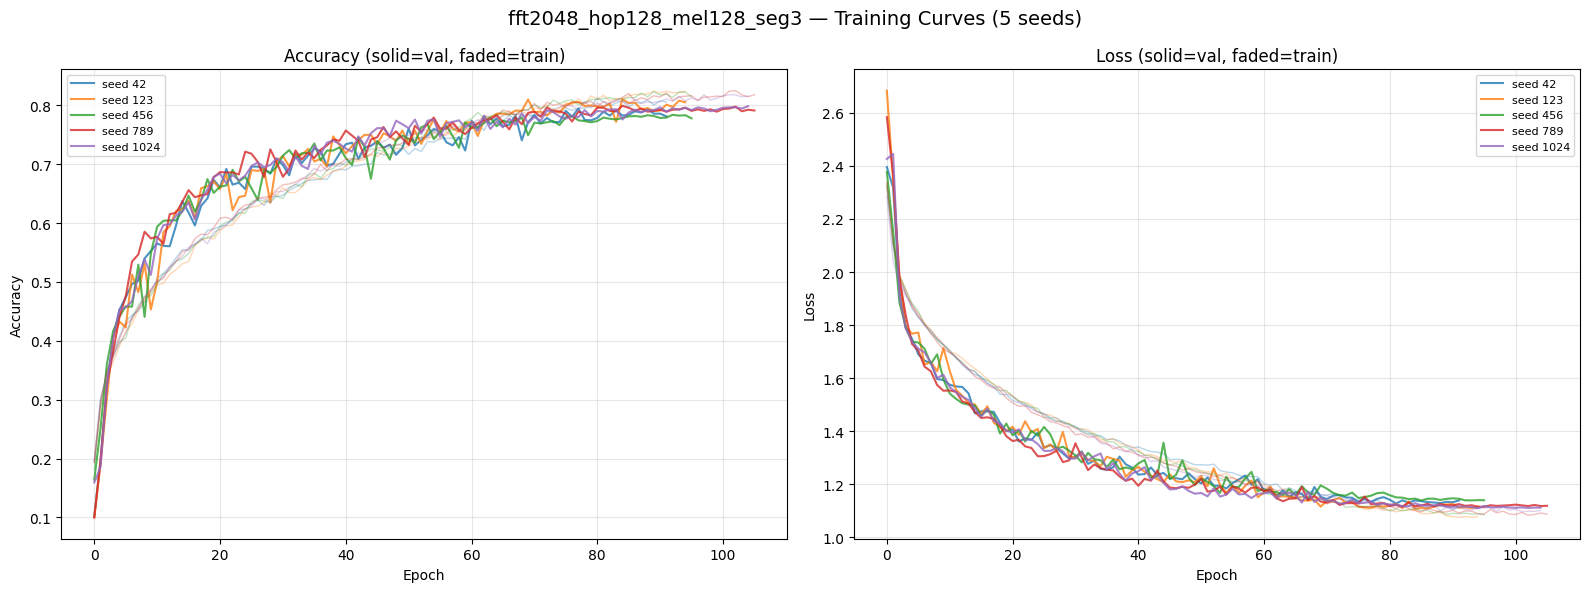

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'{CONFIG_NAME} — Training Curves ({N_RUNS} seeds)', fontsize=14)

seed_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, r in enumerate(run_results):
    c = seed_colors[idx]
    label = f"seed {r['seed']}"

    # Accuracy
    axes[0].plot(r['history']['accuracy'], color=c, alpha=0.3, linewidth=1)
    axes[0].plot(r['history']['val_accuracy'], color=c, alpha=0.8, linewidth=1.5, label=label)

    # Loss
    axes[1].plot(r['history']['loss'], color=c, alpha=0.3, linewidth=1)
    axes[1].plot(r['history']['val_loss'], color=c, alpha=0.8, linewidth=1.5, label=label)

axes[0].set_title('Accuracy (solid=val, faded=train)', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Loss (solid=val, faded=train)', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG_RESULTS_DIR, "training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

## 7. Confusion Matrix (Median Seed)

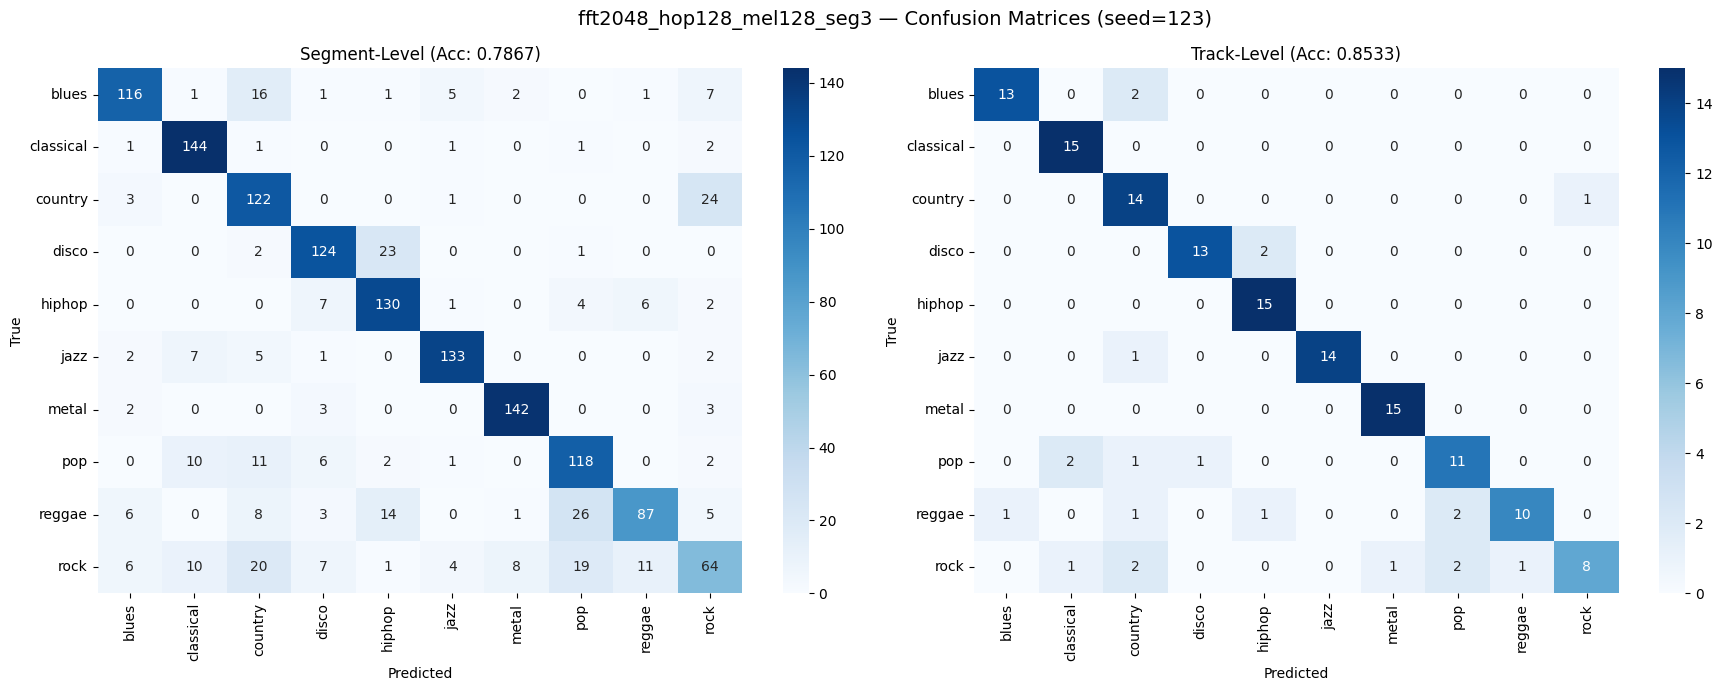

In [8]:
import seaborn as sns

# Median performansli seed'i bul
sorted_runs = sorted(run_results, key=lambda r: r['track_test_acc'])
median_run = sorted_runs[len(sorted_runs) // 2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f"{CONFIG_NAME} — Confusion Matrices (seed={median_run['seed']})", fontsize=14)

# Segment-level
cm_seg = np.array(median_run['seg_confusion_matrix'])
sns.heatmap(cm_seg, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRE_NAMES, yticklabels=GENRE_NAMES, ax=ax1)
ax1.set_title(f"Segment-Level (Acc: {median_run['seg_test_acc']:.4f})", fontsize=12)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

# Track-level
cm_track = np.array(median_run['track_confusion_matrix'])
sns.heatmap(cm_track, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRE_NAMES, yticklabels=GENRE_NAMES, ax=ax2)
ax2.set_title(f"Track-Level (Acc: {median_run['track_test_acc']:.4f})", fontsize=12)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG_RESULTS_DIR, "confusion_matrices.png"), dpi=150, bbox_inches='tight')
plt.show()

## 8. Per-Class F1 Scores

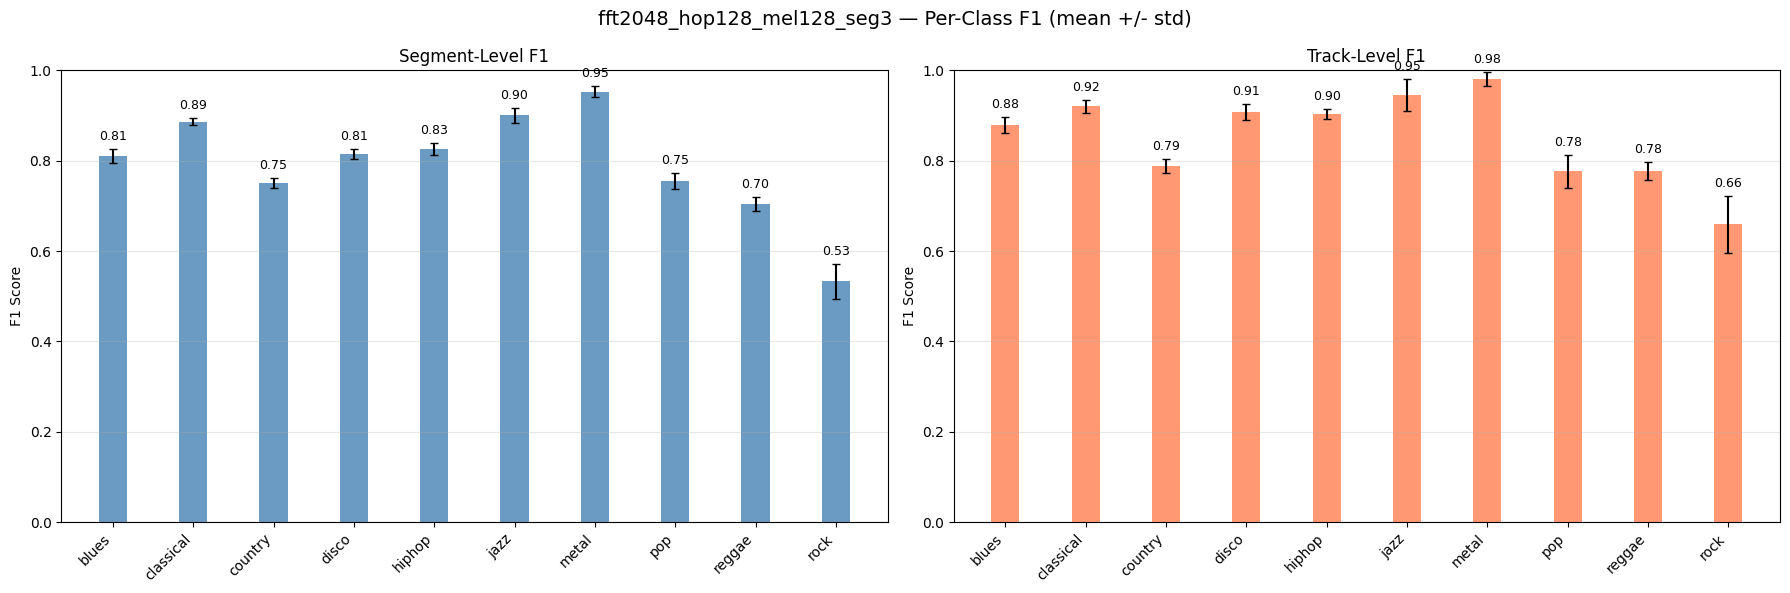


Genre                Seg F1       Track F1
------------------------------------------
blues        0.8105+/-0.0162  0.8793+/-0.0183
classical    0.8862+/-0.0077  0.9205+/-0.0139
country      0.7505+/-0.0114  0.7885+/-0.0147
disco        0.8149+/-0.0101  0.9078+/-0.0172
hiphop       0.8250+/-0.0130  0.9037+/-0.0107
jazz         0.9002+/-0.0171  0.9457+/-0.0348
metal        0.9531+/-0.0128  0.9806+/-0.0158
pop          0.7543+/-0.0180  0.7768+/-0.0362
reggae       0.7042+/-0.0156  0.7777+/-0.0195
rock         0.5327+/-0.0393  0.6595+/-0.0631


In [9]:
# Per-class F1 ortalamasi (5 seed uzerinden)
seg_f1_all   = np.array([r['seg_f1_per_class'] for r in run_results])
track_f1_all = np.array([r['track_f1_per_class'] for r in run_results])

seg_f1_mean   = seg_f1_all.mean(axis=0)
seg_f1_std    = seg_f1_all.std(axis=0)
track_f1_mean = track_f1_all.mean(axis=0)
track_f1_std  = track_f1_all.std(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'{CONFIG_NAME} — Per-Class F1 (mean +/- std)', fontsize=14)

x = np.arange(num_classes)
width = 0.35

# Segment
ax1.bar(x, seg_f1_mean, width, yerr=seg_f1_std, capsize=3, color='steelblue', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(GENRE_NAMES, rotation=45, ha='right')
ax1.set_ylabel('F1 Score')
ax1.set_title('Segment-Level F1', fontsize=12)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3, axis='y')
for i, (m, s) in enumerate(zip(seg_f1_mean, seg_f1_std)):
    ax1.text(i, m + s + 0.02, f'{m:.2f}', ha='center', fontsize=9)

# Track
ax2.bar(x, track_f1_mean, width, yerr=track_f1_std, capsize=3, color='coral', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(GENRE_NAMES, rotation=45, ha='right')
ax2.set_ylabel('F1 Score')
ax2.set_title('Track-Level F1', fontsize=12)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3, axis='y')
for i, (m, s) in enumerate(zip(track_f1_mean, track_f1_std)):
    ax2.text(i, m + s + 0.02, f'{m:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG_RESULTS_DIR, "per_class_f1.png"), dpi=150, bbox_inches='tight')
plt.show()

# Tablo olarak da yazdir
print(f"\n{'Genre':<12} {'Seg F1':>14} {'Track F1':>14}")
print("-" * 42)
for i, g in enumerate(GENRE_NAMES):
    print(f"{g:<12} {seg_f1_mean[i]:.4f}+/-{seg_f1_std[i]:.4f}  {track_f1_mean[i]:.4f}+/-{track_f1_std[i]:.4f}")

## 9. Classification Report (Median Seed)

In [10]:
# Median seed icin detayli rapor
# Tekrar predict gerekli — median seed'in modelini yukle
median_seed = median_run['seed']
median_model_path = os.path.join(CONFIG_RESULTS_DIR, f"seed_{median_seed}", "best_model.keras")

if os.path.exists(median_model_path):
    median_model = tf.keras.models.load_model(median_model_path)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_oh)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    y_pred_probs = median_model.predict(test_ds, verbose=0)
    y_pred_seg = np.argmax(y_pred_probs, axis=1)
    y_true_track, y_pred_track = majority_vote(y_test, y_pred_seg, test_track_indices)

    print(f"{'='*60}")
    print(f"  Segment-Level Classification Report (seed={median_seed})")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred_seg, target_names=GENRE_NAMES, digits=4))

    print(f"{'='*60}")
    print(f"  Track-Level Classification Report (seed={median_seed})")
    print(f"{'='*60}")
    print(classification_report(y_true_track, y_pred_track, target_names=GENRE_NAMES, digits=4))

    del median_model
    tf.keras.backend.clear_session()
    gc.collect()
else:
    print(f"Model bulunamadi: {median_model_path}")
    print("Kayitli confusion matrix'ten rapor:")
    print(f"Seg Acc: {median_run['seg_test_acc']:.4f}  Track Acc: {median_run['track_test_acc']:.4f}")

  Segment-Level Classification Report (seed=123)
              precision    recall  f1-score   support

       blues     0.8529    0.7733    0.8112       150
   classical     0.8372    0.9600    0.8944       150
     country     0.6595    0.8133    0.7284       150
       disco     0.8158    0.8267    0.8212       150
      hiphop     0.7602    0.8667    0.8100       150
        jazz     0.9110    0.8867    0.8986       150
       metal     0.9281    0.9467    0.9373       150
         pop     0.6982    0.7867    0.7398       150
      reggae     0.8286    0.5800    0.6824       150
        rock     0.5766    0.4267    0.4904       150

    accuracy                         0.7867      1500
   macro avg     0.7868    0.7867    0.7814      1500
weighted avg     0.7868    0.7867    0.7814      1500

  Track-Level Classification Report (seed=123)
              precision    recall  f1-score   support

       blues     0.9286    0.8667    0.8966        15
   classical     0.8333    1.0000   